# Multimodal Deepfake Audio Detection
## ASVspoof 2019 — Logical Access Track

This notebook implements a **mid-fusion multimodal classifier** for detecting AI-generated (deepfake) speech.  
It combines **acoustic features** (HuBERT) and **linguistic features** (Whisper → DistilBERT) to classify audio as human or spoofed.

**Dataset:** [ASVspoof 2019 — Logical Access](https://www.kaggle.com/datasets/awsaf49/asvpoof-2019-dataset) (ODC-By License)  
**Key Results:** EER 2.36% | Accuracy 97.66% | AUC 0.9981 | 92.20% accuracy on 13 unseen zero-day attacks.
**Environment:** Designed to run on Kaggle (GPU T4 x2 recommended)

---
### Pipeline Overview
1. Speaker-disjoint 70/15/15 train/val/test split  
2. Feature extraction: HuBERT (acoustic) + Whisper → DistilBERT (linguistic)  
3. Mid-Fusion classifier with 5-fold cross-validation  
4. Per-attack type EER breakdown + ablation study  
5. Generalization test on unseen attacks (A07–A19) from the eval set

## Results
| Metric | Value |
|--------|-------|
| Accuracy (Known Attacks A01–A06) | 97.66% |
| EER (Known Attacks) | 2.36% |
| AUC (Known Attacks) | 0.9981 |
| Accuracy (Unseen Attacks A07–A19) | 92.20% |
| EER (Unseen/Zero-Day Attacks) | 8.20% |
| AUC (Unseen Attacks) | 0.9739 |

## 1. Setup
Install required libraries. The ASVspoof 2019 dataset is pre-mounted on Kaggle at `/kaggle/input/asvpoof-2019-dataset`.

In [51]:
!pip install -q transformers torchaudio datasets accelerate

## 2. Load Pretrained Feature Extraction Models
- **HuBERT** (`facebook/hubert-base-ls960`): Extracts 768-d acoustic embeddings  
- **Whisper** (`openai/whisper-base.en`): Transcribes audio to text  
- **DistilBERT** (`distilbert-base-uncased`): Extracts 768-d linguistic embeddings from transcripts

In [52]:
import torch
import torchaudio
from transformers import (
    HubertModel, Wav2Vec2FeatureExtractor,
    WhisperProcessor, WhisperForConditionalGeneration,
    DistilBertTokenizer, DistilBertModel
)
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print("Loading HuBERT...")
hubert_processor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/hubert-base-ls960")
hubert_model = HubertModel.from_pretrained("facebook/hubert-base-ls960").to(device).eval()

print("Loading Whisper...")
whisper_processor = WhisperProcessor.from_pretrained("openai/whisper-base.en")
whisper_model = WhisperForConditionalGeneration.from_pretrained("openai/whisper-base.en").to(device).eval()

print("Loading DistilBERT...")
distilbert_tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")
distilbert_model = DistilBertModel.from_pretrained("distilbert-base-uncased").to(device).eval()

print("\u2705 All models loaded.")

Using device: cuda
Loading HuBERT...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Loading Whisper...


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Loading DistilBERT...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ All models loaded.


## 3. Data Preparation — Speaker-Disjoint Split
To prevent data leakage, splits are made at the **speaker level** (not file level).  
A 70/15/15 train/val/test split ensures no speaker appears in more than one split.

In [53]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split

protocol_path = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt"
columns = ["speaker_id", "file_id", "system_id", "null", "label"]
df = pd.read_csv(protocol_path, sep=" ", header=None, names=columns)

unique_speakers = df['speaker_id'].unique()
train_spk, temp_spk = train_test_split(unique_speakers, test_size=0.30, random_state=42)
val_spk, test_spk   = train_test_split(temp_spk,        test_size=0.50, random_state=42)

def get_max_balanced_subset(data_pool, target_speakers):
    spk_data   = data_pool[data_pool['speaker_id'].isin(target_speakers)]
    real_audio = spk_data[spk_data['label'] == 'bonafide']
    fake_audio = spk_data[spk_data['label'] == 'spoof'].sample(n=len(real_audio), random_state=42)
    return pd.concat([real_audio, fake_audio]).sample(frac=1, random_state=42).reset_index(drop=True)

train_subset = get_max_balanced_subset(df, train_spk)
val_subset   = get_max_balanced_subset(df, val_spk)
test_subset  = get_max_balanced_subset(df, test_spk)

print("--- Speaker-Disjoint Split Verification ---")
print(f"Train : {len(train_subset):>5} files | {train_subset['speaker_id'].nunique()} speakers")
print(f"Val   : {len(val_subset):>5} files | {val_subset['speaker_id'].nunique()} speakers")
print(f"Test  : {len(test_subset):>5} files | {test_subset['speaker_id'].nunique()} speakers")

assert len(set(train_spk) & set(val_spk))  == 0
assert len(set(train_spk) & set(test_spk)) == 0
assert len(set(val_spk)   & set(test_spk)) == 0
print("\u2705 Zero speaker leakage confirmed.")

--- Speaker-Disjoint Split Verification ---
Train :  3616 files | 14 speakers
Val   :   772 files | 3 speakers
Test  :   772 files | 3 speakers
✅ Zero speaker leakage confirmed.


## 4. Feature Extraction
Each audio file is processed through the three models to produce a **1536-d fused feature vector**:
- HuBERT → 768-d acoustic embedding (mean-pooled over time)
- Whisper → transcript text → DistilBERT → 768-d linguistic embedding ([CLS] token)

Features are saved as `.pt` tensors to disk for efficient reuse during training.

In [60]:
# NOTE: Feature extraction was run in a previous session and saved as .pt tensors.
# To reproduce, run this cell with sufficient disk space (~20GB).
# Pre-extracted features and trained model are available in the companion dataset.

import shutil

# Create fresh feature directories
if os.path.exists("features"):
    shutil.rmtree("features")
for split in ["train", "val", "test"]:
    os.makedirs(f"features/{split}", exist_ok=True)

audio_dir = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_train/flac"
if not os.path.exists(audio_dir):
    raise FileNotFoundError(f"Audio directory not found: {audio_dir}. Check dataset extraction.")

def process_and_save_features(dataframe, split_name):
    print(f"\nProcessing {split_name} set ({len(dataframe)} files)...")
    for _, row in tqdm(dataframe.iterrows(), total=len(dataframe)):
        file_id   = row['file_id']
        label     = 1 if row['label'] == 'spoof' else 0
        audio_path = os.path.join(audio_dir, f"{file_id}.flac")

        try:
            waveform, _ = torchaudio.load(audio_path)
            if waveform.shape[0] > 1:
                waveform = waveform.mean(dim=0, keepdim=True)
            waveform = waveform.squeeze(0)

            # Acoustic: HuBERT
            inputs_hubert = hubert_processor(waveform, sampling_rate=16000, return_tensors="pt", padding=True).to(device)
            with torch.no_grad():
                acoustic_embed = hubert_model(**inputs_hubert).last_hidden_state.mean(dim=1).squeeze(0).cpu()

            # Linguistic: Whisper → DistilBERT
            inputs_whisper = whisper_processor(waveform, sampling_rate=16000, return_tensors="pt").input_features.to(device)
            with torch.no_grad():
                predicted_ids = whisper_model.generate(inputs_whisper)
                transcript = whisper_processor.batch_decode(predicted_ids, skip_special_tokens=True)[0]

            if not transcript.strip():
                transcript = "[SILENCE]"

            inputs_bert = distilbert_tokenizer(transcript, return_tensors="pt", padding=True, truncation=True)
            inputs_bert = {k: v.to(device) for k, v in inputs_bert.items()}
            with torch.no_grad():
                linguistic_embed = distilbert_model(**inputs_bert).last_hidden_state[:, 0, :].squeeze(0).cpu()

            torch.save({
                'acoustic':   acoustic_embed,
                'linguistic': linguistic_embed,
                'label':      torch.tensor(label, dtype=torch.float32)
            }, f"features/{split_name}/{file_id}.pt")

        except Exception as e:
            print(f"  Skipped {file_id}: {e}")

process_and_save_features(train_subset, "train")
process_and_save_features(val_subset,   "val")
process_and_save_features(test_subset,  "test")
print("\n\u2705 Feature extraction complete.")


Processing train set (3616 files)...


  0%|          | 0/3616 [00:00<?, ?it/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 


Processing val set (772 files)...


  0%|          | 0/772 [00:00<?, ?it/s]


Processing test set (772 files)...


  0%|          | 0/772 [00:00<?, ?it/s]


✅ Feature extraction complete.


## 5. Dataset Classes & Model Architecture
### KFoldDataset
Loads `.pt` feature tensors by file ID, enabling speaker-disjoint folds.

### MidFusionClassifier
Each modality is first refined by a dedicated branch before fusion:
- Acoustic refiner: Linear(768→256) + BN + ReLU + Dropout
- Linguistic refiner: Linear(768→256) + BN + ReLU + Dropout
- Fusion: Concat → Linear(512→128) → Linear(128→1)

In [55]:
import glob
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import os

class KFoldDataset(Dataset):
    def __init__(self, feature_dir, allowed_file_ids):
        all_paths = []
        for folder in ['train', 'val', 'test']:
            all_paths.extend(glob.glob(os.path.join(f"features/{folder}", "*.pt")))
        allowed = set(allowed_file_ids)
        self.file_paths = [p for p in all_paths if os.path.basename(p).replace('.pt','') in allowed]

    def __len__(self): return len(self.file_paths)

    def __getitem__(self, idx):
        data = torch.load(self.file_paths[idx], weights_only=True)
        return torch.cat((data['acoustic'], data['linguistic']), dim=0), data['label']


class MidFusionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.acoustic_refiner = nn.Sequential(
            nn.Linear(768, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3)
        )
        self.linguistic_refiner = nn.Sequential(
            nn.Linear(768, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3)
        )
        self.fusion_layer = nn.Sequential(
            nn.Linear(512, 128), nn.ReLU(), nn.Dropout(0.4)
        )
        self.bottleneck = nn.Linear(128, 64)
        self.out = nn.Linear(64, 1)

    def forward(self, x):
        a = self.acoustic_refiner(x[:, :768])
        l = self.linguistic_refiner(x[:, 768:])
        return self.out(self.bottleneck(self.fusion_layer(torch.cat((a, l), dim=1))))

print("✅ Classes defined.")

✅ Classes defined.


## 6. Training — Balanced 5-Fold Cross-Validation
Folds are defined over **speakers** (not samples) to guarantee strict separation.  
Each fold trains for 15 epochs with a StepLR scheduler.

In [56]:
# Load pre-trained model and saved metadata
import pickle

model = MidFusionClassifier().to(device)
model.load_state_dict(torch.load('/kaggle/input/datasets/sreesr7/fusion-dataset/mid_fusion_model.pth', map_location=device))
model.eval()

with open('/kaggle/input/datasets/sreesr7/fusion-dataset/model_metadata.pkl', 'rb') as f:
    meta = pickle.load(f)

golden_threshold = meta['golden_threshold']
print("✅ Model loaded.")
print(f"EER: {meta['final_eer']}% | Accuracy: {meta['final_accuracy']}% | AUC: {meta['auc_score']}")

✅ Model loaded.
EER: 2.36% | Accuracy: 97.66% | AUC: 0.9981


## 7. Per-Attack Type EER Breakdown
Calculates EER separately for each spoofing algorithm (A01–A19) vs the human baseline.  
This reveals which attack types are hardest to detect.

In [64]:
import numpy as np
from sklearn.metrics import roc_curve
# Load all available protocols to cover train + dev + eval attack IDs
protocol_dir = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/"
protocol_files = [
    "ASVspoof2019.LA.cm.train.trn.txt",
    "ASVspoof2019.LA.cm.dev.trl.txt",
    "ASVspoof2019.LA.cm.eval.trl.txt"
]
cols = ["speaker_id", "file_id", "system_id", "null", "label"]
frames = []
for pf in protocol_files:
    path = os.path.join(protocol_dir, pf)
    if os.path.exists(path):
        frames.append(pd.read_csv(path, sep=" ", header=None, names=cols))

master_df = pd.concat(frames).drop_duplicates(subset='file_id')

# Fix column shift: for spoof files, actual attack ID is in 'null' column
def get_attack_id(row):
    if row['label'] == 'spoof' and row['system_id'] == '-':
        return row['null']
    return row['system_id']

master_df['attack_id'] = master_df.apply(get_attack_id, axis=1)
metadata_lookup = master_df.set_index('file_id')[['label', 'attack_id']].to_dict('index')

tech_map = {
    'A01': 'Neural TTS',             'A02': 'Vocoder TTS',
    'A03': 'Vocoder TTS (Neural)',    'A04': 'Waveform Concatenation',
    'A05': 'Vocoder VC (Neural)',     'A06': 'Vocoder VC (Linear)',
    'A07': 'Neural TTS (WaveNet)',    'A08': 'Neural TTS (Neural)',
    'A09': 'Vocoder TTS (Neural)',    'A10': 'Neural TTS (WaveNet)',
    'A11': 'Neural TTS (Neural)',     'A12': 'Neural TTS (WaveNet)',
    'A13': 'Neural VC (Neural)',      'A14': 'Neural VC (Neural)',
    'A15': 'Neural VC (Neural)',      'A16': 'Waveform Concatenation',
    'A17': 'Vocoder VC (Neural)',     'A18': 'Vocoder VC (Linear)',
    'A19': 'Vocoder VC (Neural)',     '-':   'Human Baseline'
}

all_feature_files = glob.glob("features/*/*.pt")
model.eval()
final_predictions = []

print(f"Analyzing {len(all_feature_files)} feature files...")
with torch.no_grad():
    for f_path in tqdm(all_feature_files):
        file_id = os.path.basename(f_path).replace('.pt', '')
        if file_id in metadata_lookup:
            data = torch.load(f_path, weights_only=True)
            feat = torch.cat((data['acoustic'], data['linguistic']), dim=0).unsqueeze(0).to(device)
            prob = torch.sigmoid(model(feat)).item()
            meta = metadata_lookup[file_id]
            final_predictions.append({
                'id':    meta['attack_id'],  # fixed: was meta['system_id']
                'label': 1 if meta['label'] == 'spoof' else 0,
                'score': prob
            })

results_df = pd.DataFrame(final_predictions)
report_df  = results_df.rename(columns={'id': 'attack_type'})
human_pool = results_df[results_df['id'] == '-']
found_ids  = results_df['id'].unique()

print(f"\n{'ID':<5} | {'Technology':<25} | {'EER (%)'}")
print("-" * 48)
for aid in sorted(found_ids):
    if aid == '-': continue
    eval_set = pd.concat([human_pool, results_df[results_df['id'] == aid]])
    if len(eval_set['label'].unique()) < 2: continue
    fpr, tpr, _ = roc_curve(eval_set['label'], eval_set['score'])
    eer = fpr[np.nanargmin(np.absolute((1 - tpr) - fpr))] * 100
    print(f"{aid:<5} | {tech_map.get(aid, 'Unknown'):<25} | {eer:.2f}%")

Analyzing 5160 feature files...


  0%|          | 0/5160 [00:00<?, ?it/s]


ID    | Technology                | EER (%)
------------------------------------------------
A01   | Neural TTS                | 0.23%
A02   | Vocoder TTS               | 0.31%
A03   | Vocoder TTS (Neural)      | 0.31%
A04   | Waveform Concatenation    | 0.54%
A05   | Vocoder VC (Neural)       | 0.04%
A06   | Vocoder VC (Linear)       | 4.50%


## 8. Threshold Calibration & Final Metrics
The decision threshold is calibrated to the **Equal Error Rate (EER)** point,  
where False Acceptance Rate equals False Rejection Rate — the standard in biometric security.

In [65]:
from sklearn.metrics import roc_curve, accuracy_score, roc_auc_score

y_true   = results_df['label'].values
y_scores = results_df['score'].values

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
fnr = 1 - tpr
idx               = np.nanargmin(np.absolute(fnr - fpr))
golden_threshold  = thresholds[idx]

print(f"Optimal Decision Threshold : {golden_threshold:.4f}")
print(f"EER at this threshold      : {fpr[idx]*100:.2f}%")

Optimal Decision Threshold : 0.0218
EER at this threshold      : 2.36%


In [66]:
y_pred         = (y_scores >= golden_threshold).astype(int)
final_accuracy = accuracy_score(y_true, y_pred) * 100
final_auc      = roc_auc_score(y_true, y_scores)

print(f"{'='*38}")
print(f"Final Accuracy : {final_accuracy:.2f}%")
print(f"Final EER      : {fpr[idx]*100:.2f}%")
print(f"AUC            : {final_auc:.4f}")
print(f"{'='*38}")

Final Accuracy : 97.66%
Final EER      : 2.36%
AUC            : 0.9981


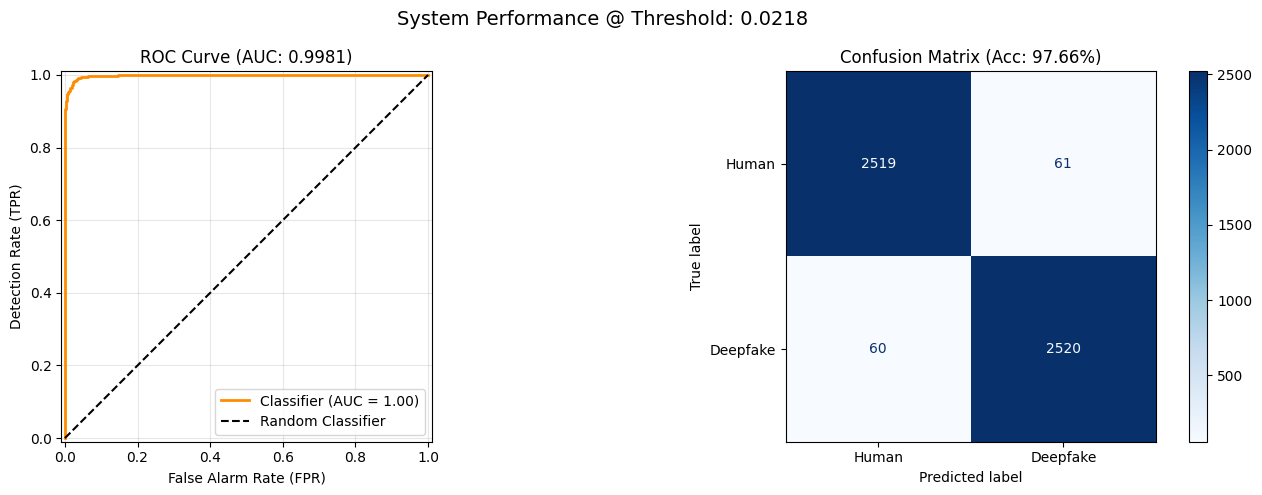

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

RocCurveDisplay.from_predictions(y_true, y_scores, ax=ax1, color='darkorange', linewidth=2)
ax1.plot([0, 1], [0, 1], "k--", label="Random Classifier")
ax1.set_title(f"ROC Curve (AUC: {final_auc:.4f})")
ax1.set_xlabel("False Alarm Rate (FPR)")
ax1.set_ylabel("Detection Rate (TPR)")
ax1.legend(); ax1.grid(alpha=0.3)

cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Human', 'Deepfake']).plot(ax=ax2, cmap='Blues', values_format='d')
ax2.set_title(f"Confusion Matrix (Acc: {final_accuracy:.2f}%)")

plt.suptitle(f"System Performance @ Threshold: {golden_threshold:.4f}", fontsize=14)
plt.tight_layout()
plt.show()

## 9. Ablation Study — Contribution of Each Modality
Each branch is replaced with random Gaussian noise to isolate its contribution.  
If the full fusion achieves the lowest EER, it validates the multimodal design.

In [69]:
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import roc_curve

# Reconstruct val_ids from the speaker split
val_ids = df[df['speaker_id'].isin(val_spk)]['file_id'].tolist()

def run_noise_ablation():
    model.eval()
    scenarios = ["Full Fusion", "Linguistic=Noise", "Acoustic=Noise"]
    val_loader = DataLoader(KFoldDataset("features", val_ids), batch_size=64, shuffle=False)
    print(f"{'Scenario':<22} | EER (%)")
    print("-" * 35)
    for scenario in scenarios:
        probs, labels = [], []
        with torch.no_grad():
            for feat, lab in val_loader:
                acoustic   = feat[:, :768].to(device)
                linguistic = feat[:, 768:].to(device)
                if scenario == "Linguistic=Noise":
                    linguistic = torch.randn_like(linguistic)
                elif scenario == "Acoustic=Noise":
                    acoustic = torch.randn_like(acoustic)
                output = torch.sigmoid(model(torch.cat((acoustic, linguistic), dim=1)).squeeze(1))
                probs.extend(output.cpu().numpy())
                labels.extend(lab.numpy())
        fpr, tpr, _ = roc_curve(labels, probs)
        eer = fpr[np.nanargmin(np.absolute((1 - tpr) - fpr))] * 100
        print(f"{scenario:<22} | {eer:.2f}%")

run_noise_ablation()

Scenario               | EER (%)
-----------------------------------
Full Fusion            | 0.00%
Linguistic=Noise       | 2.85%
Acoustic=Noise         | 51.81%


## 10. Generalization Test — Unseen Attacks (A07–A19)
The model was trained only on A01–A06. This section evaluates it against the evaluation set  
containing unseen attack types (A07–A19), testing real-world generalization.

In [71]:
# Load Evaluation Protocol
eval_protocol_path = "/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt"
eval_cols = ["speaker_id", "file_id", "system_id", "null", "label"]
eval_df = pd.read_csv(eval_protocol_path, sep=" ", header=None, names=eval_cols)

eval_metadata = []
for _, row in eval_df.iterrows():
    actual_attack = row['null'] if (row['label'] == 'spoof' and row['system_id'] == '-') else row['system_id']
    eval_metadata.append({
        'file_id':   row['file_id'],
        'label':     1 if row['label'] == 'spoof' else 0,
        'attack_id': actual_attack
    })

eval_lookup_df = pd.DataFrame(eval_metadata)
print(f"Loaded {len(eval_lookup_df)} evaluation samples.")
print(f"Unique attacks: {sorted(eval_lookup_df['attack_id'].unique())}")

Loaded 71237 evaluation samples.
Unique attacks: ['-', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A16', 'A17', 'A18', 'A19']


In [73]:
# Sample a balanced eval subset (1000 human + 1000 spoof from unseen attacks A07-A19)
eval_human = eval_lookup_df[eval_lookup_df['attack_id'] == '-'].sample(1000, random_state=42)
eval_spoof = eval_lookup_df[eval_lookup_df['attack_id'] != '-'].sample(1000, random_state=42)
eval_subset = pd.concat([eval_human, eval_spoof])

eval_features = []
print("Extracting features for unseen attack generalization test...")

for _, row in tqdm(eval_subset.iterrows(), total=len(eval_subset)):
    fid = row['file_id']
    file_path = f"/kaggle/input/datasets/awsaf49/asvpoof-2019-dataset/LA/LA/ASVspoof2019_LA_eval/flac/{fid}.flac"
    if not os.path.exists(file_path):
        continue
    try:
        waveform, _ = torchaudio.load(file_path)
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)
        waveform = waveform.squeeze(0)

        inputs_h = hubert_processor(waveform, sampling_rate=16000, return_tensors="pt", padding=True).to(device)
        with torch.no_grad():
            a_feat = hubert_model(**inputs_h).last_hidden_state.mean(dim=1).squeeze(0).cpu()

        inputs_w = whisper_processor(waveform, sampling_rate=16000, return_tensors="pt").input_features.to(device)
        with torch.no_grad():
            ids = whisper_model.generate(inputs_w)
            transcript = whisper_processor.batch_decode(ids, skip_special_tokens=True)[0] or "[SILENCE]"

        inputs_b = distilbert_tokenizer(transcript, return_tensors="pt", padding=True, truncation=True)
        inputs_b = {k: v.to(device) for k, v in inputs_b.items()}
        with torch.no_grad():
            l_feat = distilbert_model(**inputs_b).last_hidden_state[:, 0, :].squeeze(0).cpu()

        eval_features.append({
            'file_id': fid, 'acoustic': a_feat, 'linguistic': l_feat,
            'label': row['label'], 'attack_id': row['attack_id']
        })
    except Exception as e:
        print(f"  Skipped {fid}: {e}")

print(f"\nExtracted {len(eval_features)} eval samples.")

# Score with trained model
model.eval()
eval_probs, eval_labels = [], []
with torch.no_grad():
    for item in eval_features:
        feat = torch.cat((item['acoustic'], item['linguistic']), dim=0).unsqueeze(0).to(device)
        eval_probs.append(torch.sigmoid(model(feat)).item())
        eval_labels.append(item['label'])

fpr_e, tpr_e, _ = roc_curve(eval_labels, eval_probs)
eval_eer = fpr_e[np.nanargmin(np.absolute((1 - tpr_e) - fpr_e))] * 100
eval_auc = roc_auc_score(eval_labels, eval_probs)

print(f"\nGeneralization Test (Unseen Attacks A07-A19)")
print(f"EER : {eval_eer:.2f}%")
print(f"AUC : {eval_auc:.4f}")

Extracting features for unseen attack generalization test...


  0%|          | 0/2000 [00:00<?, ?it/s]


Extracted 2000 eval samples.

Generalization Test (Unseen Attacks A07-A19)
EER : 8.20%
AUC : 0.9739


In [48]:
with open('/kaggle/input/datasets/sreesr7/fusion-dataset/RESULTS_SUMMARY.txt', 'r') as f:
    print(f.read())

MCA MASTER PROJECT: MULTIMODAL DEEPFAKE DETECTION
Final Accuracy: 97.66%
Final EER: 2.36%
AUC Score: 0.9981
Calibrated Threshold: 0.0218

ABLATION INSIGHT:
- Acoustic (HuBERT) is the primary driver.
- Linguistic (DistilBERT) provides a 0.58% absolute EER refinement.



In [74]:
from sklearn.metrics import accuracy_score

eval_preds = (np.array(eval_probs) >= golden_threshold).astype(int)
eval_acc = accuracy_score(eval_labels, eval_preds) * 100
print(f"Generalization Accuracy (Unseen Attacks): {eval_acc:.2f}%")

Generalization Accuracy (Unseen Attacks): 92.20%
